# Machine learning approach 

During this notebook, we are testing different ML algorithms to tackle hypoglycemia prediction problem  

Create our own class to compare different models against several horizons and metrics

In [20]:
import os 
import pandas as pd 
import numpy as np 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [22]:
class Models_Horizon():
    def __init__(self, cut_point:int, test_size:float , window_size:int, horizon:int, folds:int, models:list, model_names:list, metrics:list):
        self.cut_point = cut_point
        self.test_size = test_size
        self.window_size = window_size
        self.horizon = horizon
        self.folds = folds
        self.models = models
        self.model_names = model_names
        self.metrics = metrics


        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        spliter = TimeSeriesSplit(n_splits=self.folds, test_size=288) ## We test using one day
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            patients[key] = []
            data = pd.read_csv(fp, sep=';')[:self.cut_point]['glucose']
            for k_fold in spliter.split(data):
                k_train = data[k_fold[0]]
                k_test = data[k_fold[1]]
                proper_ml_train_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_train, window_size=self.window_size, horizon=self.horizon)
                proper_ml_test_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_test, window_size=self.window_size, horizon=self.horizon)
                patients[key].append((proper_ml_train_k_fold.generated_data_set, proper_ml_test_k_fold.generated_data_set))
        return patients
    
    def test_models(self):
        keys = list(self.patients.keys())
        results = []
        for key in keys:
            data_folds = self.patients[key] ## A list of tuples 
            columns = data_folds[0][0].columns ## Just to extract columns
            tensor_results_metrics = np.zeros(shape=(len(self.model_names), len(self.metrics), self.folds)) ## 3 cause, we're measuring MSE,MAE and MAPE

            for k, fold in enumerate(data_folds):
                train_k, test_k = fold[0], fold[1]
                X_train_k, y_train_k = train_k[columns[:-1]], train_k[columns[-1]]
                X_test_k, y_test_k = test_k[columns[:-1]], test_k[columns[-1]]
                for m, model in enumerate(self.models):
                    model = clone(model)
                    model.fit(X_train_k, y_train_k)
                    y_pred_k = model.predict(X_test_k)
                    for z, metric in enumerate(self.metrics):
                        result_metric = metric(y_true=y_test_k, y_pred=y_pred_k)
                        tensor_results_metrics[m][z][k] = result_metric
                        
            mse_all_models = tensor_results_metrics[:, 0, :]
            mae_all_models = tensor_results_metrics[:, 1, :]
            mape_all_models = tensor_results_metrics[:, 2, :]

            results.append(list(np.mean(mse_all_models, axis=1)) + list(np.mean(mae_all_models, axis=1)) + list(np.mean(mape_all_models, axis=1)))

        ### Prepare and return a df 
        metrics = ['mse', 'mae', 'mape']
        col_index = pd.MultiIndex.from_product([metrics, self.model_names], names=['metric', 'model'])
        df_final = pd.DataFrame(
            results,
            index=keys,
            columns=col_index
        )
        self.results = df_final
        return df_final

    def visualize_model_comparison(self, figsize=(15, 7)):
        if self.results is None:
            raise ValueError("No results to visualize. Run 'test_models()' first.")
    

        metrics = ['mse', 'mae', 'mape']
        model_names = self.model_names

        _, axes = plt.subplots(1, 3, figsize=figsize)
        colors = ['steelblue', 'seagreen', 'tomato']

        for ax, metric, color in zip(axes, metrics, colors):

            data_plot = self.results[metric]  

            data_long = data_plot.reset_index().melt(
                id_vars='index',
                var_name='Model',
                value_name=metric.upper()
            )
            data_long['Model'] = pd.Categorical(data_long['Model'], categories=model_names)

    
            sns.boxplot(
                data=data_long,
                x='Model',
                y=metric.upper(),
                ax=ax,
                color=color,
                width=0.6
            )

            ax.set_title(f'{metric.upper()}: Window_size:{self.window_size}, Horizon:{self.horizon}')
            ax.set_xlabel('Modelo')
            ax.set_ylabel(metric.upper())
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        ## Visualize a summary for each metric
        for m in metrics:
            print(f'{m.upper()}')
            print(self.results[m].describe())
        

## Test it using random forest regressor and gradient boost regressor 

In [25]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


In [27]:
cut_point = 2290
test_size = 0.2
window_size = 6
horizon = 6
folds = 5
models = [
    RandomForestRegressor(
        n_estimators=100,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_child_weight=10,  
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ),
    Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(0,1))), ('model', LinearRegression())]),
    Pipeline(steps=[
        ('scaler', MinMaxScaler(feature_range=(0, 1))),
        ('model', RidgeCV(
            alphas=np.logspace(-4, 4, 50),   # ajustable
            cv=None,                         # ← GCV
            store_cv_results=False
        ))
    ])

]
model_names = ['random_forest', 'gradient_boost', 'xgboost', 'linear_regression', 'ridge_regression']
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]

In [28]:
horizon_3 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=horizon, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

In [29]:
results = horizon_3.test_models()

In [ ]:
results.shape

(25, 15)

In [ ]:
results

metric              mse                 ...              mape                 
model     random_forest gradient_boost  ... linear_regression ridge_regression
HUPA0004P    854.190016     497.505012  ...          0.100726         0.138918
HUPA0006P    820.230737     642.099247  ...          0.082896         0.107894
HUPA0007P   1295.452377    1060.447275  ...          0.156503         0.163386
HUPA0009P    210.556321     220.828381  ...          0.019125         0.030968
HUPA0005P    383.253171     358.160958  ...          0.094800         0.103086
HUPA0011P   1008.687368     871.109361  ...          0.111219         0.126520
HUPA0003P    564.611648     507.419767  ...          0.115764         0.129596
HUPA0001P   1256.354694    1093.971139  ...          0.129162         0.138085
HUPA0010P    714.692895     483.436316  ...          0.096384         0.114954
HUPA0002P    372.473976     313.528771  ...          0.091009         0.112854
HUPA0014P   1075.266157     945.553426  ...          0.074826         0.091902
HUPA0015P    679.550085     516.527394  ...          0.090392         0.115955
HUPA0016P    599.597948     439.887824  ...          0.091184         0.111940
HUPA0017P    474.469511     379.089502  ...          0.072681         0.085883
HUPA0018P    683.161673     473.107637  ...          0.096033         0.121997
HUPA0021P    691.885507     565.616184  ...          0.092970         0.107383
HUPA0020P    605.991973     430.646840  ...          0.071381         0.093814
HUPA0024P    557.600609     333.716352  ...          0.072323         0.091890
HUPA0019P   1040.831182     713.596956  ...          0.099808         0.120887
HUPA0023P    497.454089     416.849745  ...          0.078860         0.092782
HUPA0022P    291.147622     286.472501  ...          0.107510         0.114057
HUPA0025P    289.089956     252.587499  ...          0.091016         0.104243
HUPA0028P    528.520752     432.249373  ...          0.115995         0.132376
HUPA0026P    585.406845     420.288815  ...          0.096465         0.122118
HUPA0027P    293.331342     252.223613  ...          0.082235         0.094005

[25 rows x 15 columns]

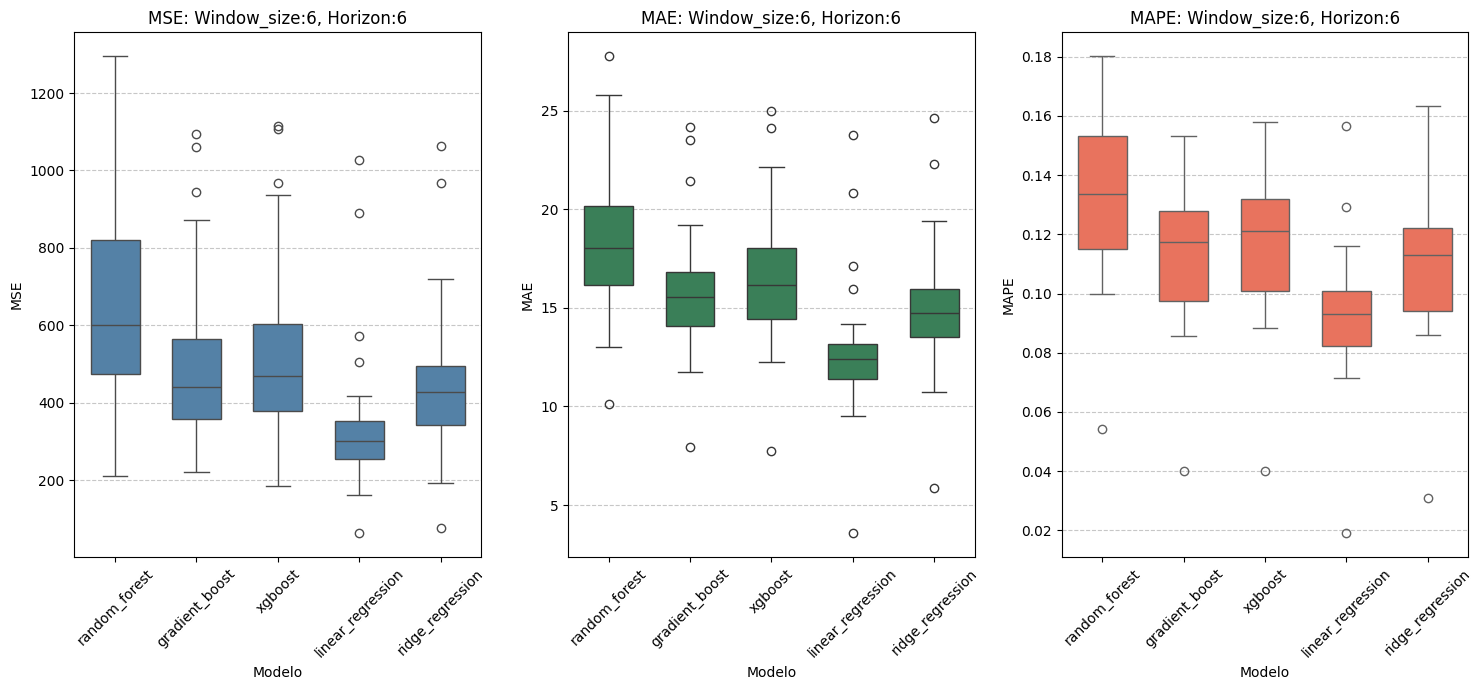

MSE
model  random_forest  gradient_boost  ...  linear_regression  ridge_regression
count      25.000000       25.000000  ...          25.000000         25.000000
mean      654.952338      516.276795  ...         351.810833        446.330834
std       298.980813      244.740549  ...         210.151150        221.211124
min       210.556321      220.828381  ...          63.172596         75.754408
25%       474.469511      358.160958  ...         254.554131        341.066121
50%       599.597948      439.887824  ...         301.788630        427.048802
75%       820.230737      565.616184  ...         351.756402        493.672884
max      1295.452377     1093.971139  ...        1027.038549       1064.589059

[8 rows x 5 columns]
MAE
model  random_forest  gradient_boost  ...  linear_regression  ridge_regression
count      25.000000       25.000000  ...          25.000000         25.000000
mean       18.338656       15.853119  ...          12.798394         15.087869
std         4.165335  

In [ ]:
horizon_3.visualize_model_comparison()